# building a neutral network

### use pytorch to build

In [3]:
import torch
import torch.nn as nn

# 1. 创建 PyTorch 张量（而不是 NumPy 数组）
x = torch.tensor([200.0, 17.0], dtype=torch.float32)

# 2. 定义层：输入特征数 = 2（因为 x 有两个值）
layer_1 = nn.Linear(in_features=2, out_features=3)

# 3. 前向传播
a1 = torch.sigmoid(layer_1(x))
print(a1)
layer_2 = nn.Linear(in_features=3,out_features=1)
a2 = torch.sigmoid(layer_2(a1))

print(a2)

tensor([1., 1., 1.], grad_fn=<SigmoidBackward0>)
tensor([0.3169], grad_fn=<SigmoidBackward0>)


In [ ]:
import numpy as np
import torch.optim as optim

# data:
x = np.array([[200.0, 17.0],
              [120.0, 5.0],
              [425.0, 20.0],
              [212.0, 18.0]], dtype='float32')
y = np.array([[1], [0], [0], [1]], dtype="float32")
tensorx = torch.tensor(x); tensory = torch.tensor(y)

# this is your model:
model = nn.Sequential(
    nn.Linear(2, 3),
    nn.Sigmoid(),
    nn.Linear(3, 1),
    nn.Sigmoid()
)


# compile: 
loss_fn = nn.BCELoss() #
optimizer = optim.SGD(model.parameters(), lr = 0.01) 

# in Pytorch there isn't having a function "fit", 
# you should implement by yourself:
for epoch in range(100):
    y_pred = model(tensorx)
    loss = loss_fn(y_pred, tensory)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch:4d}, Loss: {loss.item():.4f}')    
print(model(tensorx))

Epoch    0, Loss: 0.7282
tensor([[0.4509],
        [0.4509],
        [0.4509],
        [0.4509]], grad_fn=<SigmoidBackward0>)


# Forward prop in a single layer

let's take a look at **how you implement for a prop for a single layer**
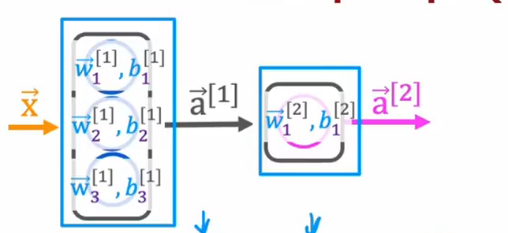

in layer_1 there have three neurons, let's see the detail of compute,

for example x = np.array([200, 17])

and $a^{[1]}_1 = g(\vec{w_1}^{[1]} \cdot \vec 0x + b^{[1]}_1)$
$w^{[1]}_1$ = np.array([1,2])

$b^{[1]}_1$ = np.array([-1])

$z^{[1]}_1$ = np.dot($w^{[1]}_1$, x) + $b^{[1]}_1$

$a^{[1]}_1$ = sigmoid($z^{[1]}_1$)a

and also $a^{[2]}_1$, $a^{[3]}_1$

# General implemetation of forward propagation 

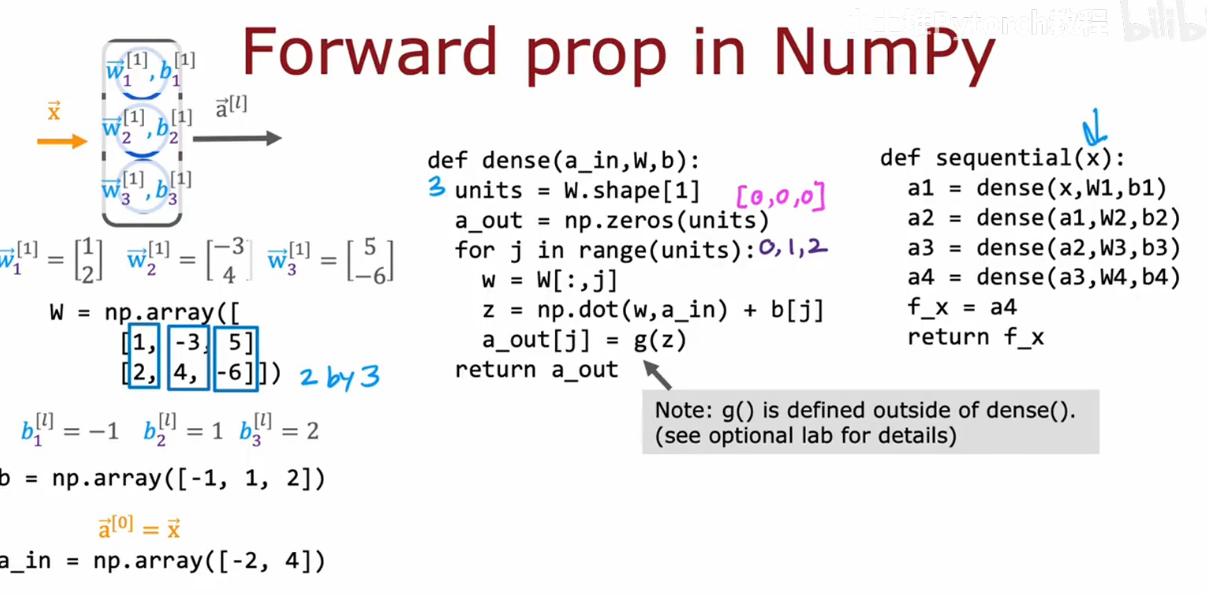

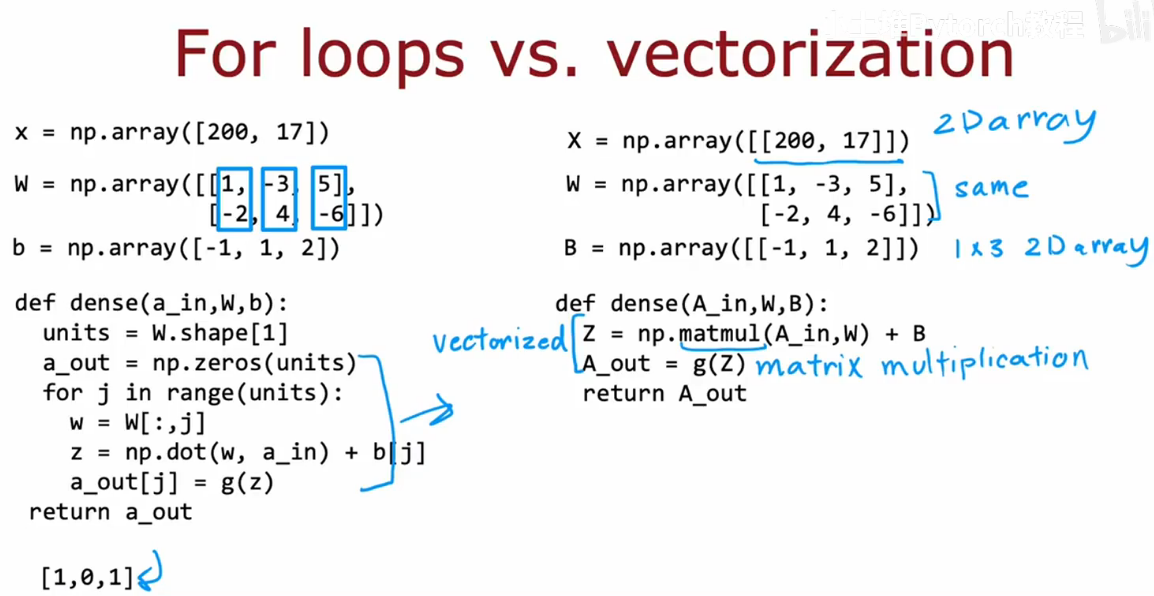

# Build a neutral network

1. specify how to compute output given input $x$ and paramerters $w,b$(define model)  $f_{\vec w, b}(\vec x) = ?$
2. specify loss and cost $L(f_{\vec w, b}(\vec x), y)$ 1 example $J(\vec w, b)$
3. Train on data to minimize $J(\vec w, b)$ 
4. $J(\vec w, b)$ is called logisticloss also known as binary cross entropy(loss_fn = nn.BCELoss())